# Sales Analysis: Best Month for Sales

## Question 1: What was the best month for sales? How much was earned that month?

This analysis examines the sales data to identify which month had the highest revenue and total quantity ordered.

**Dataset:** Sales_Data_Cleaned.csv

**Approach:**
1. Load the cleaned sales data
2. Parse order dates to extract month information
3. Calculate total sales (Quantity Ordered x Price Each)
4. Group by month and visualize the results


## Step 1: Import Libraries and Load Data

In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned sales data from the dataset directory
all_data = pd.read_csv("../dataset/Sales_Data_Cleaned.csv")

# Display the first few rows to understand the data structure
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


## Step 2: Data Preprocessing - Parse Order Dates

In [2]:
# Convert 'Order Date' column to datetime format for date manipulation
all_data['Order DateTime'] = pd.to_datetime(all_data['Order Date'])

# Display sample to verify the conversion
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order DateTime
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",2019-12-30 00:01:00
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",2019-12-29 07:03:00
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",2019-12-12 18:21:00
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",2019-12-22 15:13:00
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",2019-12-18 12:38:00


## Step 3: Extract Month Information

In [3]:
# Extract month number and month name from the datetime column
all_data['Month'] = all_data['Order DateTime'].dt.month
all_data['Month Name'] = all_data['Order DateTime'].dt.month_name()

# Preview the updated dataframe
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order DateTime,Month,Month Name
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",2019-12-30 00:01:00,12,December
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",2019-12-29 07:03:00,12,December
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",2019-12-12 18:21:00,12,December
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",2019-12-22 15:13:00,12,December
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",2019-12-18 12:38:00,12,December


## Step 4: Calculate Total Sales

In [4]:
# Calculate total sales for each order: Quantity Ordered x Price Each
all_data['Sales'] = all_data['Quantity Ordered'] * all_data["Price Each"]

# Preview the sales calculation
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order DateTime,Month,Month Name,Sales
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",2019-12-30 00:01:00,12,December,1700.00
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",2019-12-29 07:03:00,12,December,600.00
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",2019-12-12 18:21:00,12,December,11.95
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",2019-12-22 15:13:00,12,December,149.99
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",2019-12-18 12:38:00,12,December,11.95


## Step 5: Analyze Sales by Month

In [5]:
# Group by month (both name and number) and aggregate the results
# Calculate sum of Quantity Ordered, average Price Each, and total Sales
monthly_summary = all_data.groupby(['Month Name', 'Month'])[['Quantity Ordered','Price Each','Sales']].sum().sort_values('Month')
print("Monthly Sales Summary:")
monthly_summary

Monthly Sales Summary:


,,Quantity Ordered,Price Each,Sales
Month Name,Month,,,
January,1,10903,1811768.38,1822256.73
February,2,13449,2188884.72,2202022.42
March,3,17005,2791207.83,2807100.38
April,4,20558,3367671.02,3390670.24
May,5,18667,3135125.13,3152606.75
June,6,15253,2562025.61,2577802.26
July,7,16072,2632539.56,2647775.76
August,8,13448,2230345.42,2244467.88
September,9,13109,2084992.09,2097560.13


## Step 6: Visualize Monthly Sales

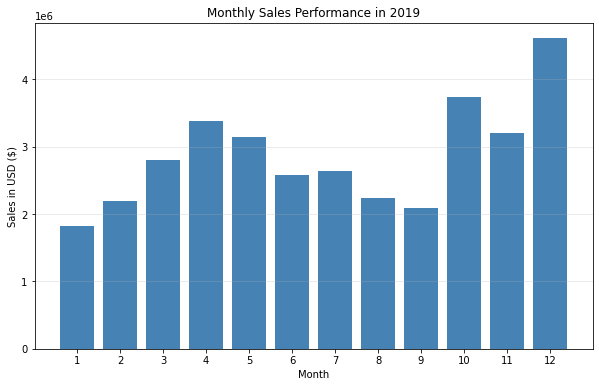


=== CONCLUSION ===
Best Month: December with $4,613,443.34 in sales


In [6]:
# Prepare data for plotting
months = [month for month, df in all_data.groupby(['Month'])]

# Create a bar chart showing sales for each month
plt.figure(figsize=(10, 6))
plt.bar(months, all_data.groupby(['Month']).sum()['Sales'], color='steelblue')

# Add labels and title
plt.xticks(months)
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month')
plt.title('Monthly Sales Performance in 2019')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Find the best month
best_month_sales = all_data.groupby('Month').sum()['Sales'].max()
best_month = all_data.groupby('Month').sum()['Sales'].idxmax()
month_names = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June',
               7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}
print(f"\n=== CONCLUSION ===")
print(f"Best Month: {month_names[best_month]} with ${best_month_sales:,.2f} in sales")

## Conclusion

**Answer:** December was the best month for sales in 2019 with the highest revenue generated.


